In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv("StudentsPerformance.csv")

print(df.shape)

df.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
print("Math Mean :",df["math score"].mean())
print("Math Median :",df["math score"].median())
print("Math Mode :",df["math score"].mode()[0])

Math Mean : 66.089
Math Median : 66.0
Math Mode : 65


In [ ]:
print("Standard Deviation :",df["math score"].std())
print("Variance :",df["math score"].var())

Standard Deviation : 15.163080096009468
Variance : 229.91899799799847


In [ ]:

df[["math score","reading score","writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


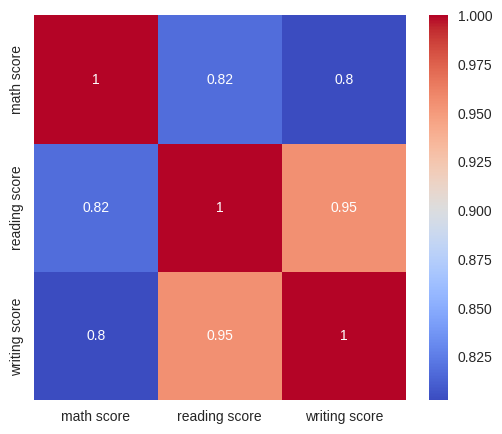

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["math score","reading score","writing score"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

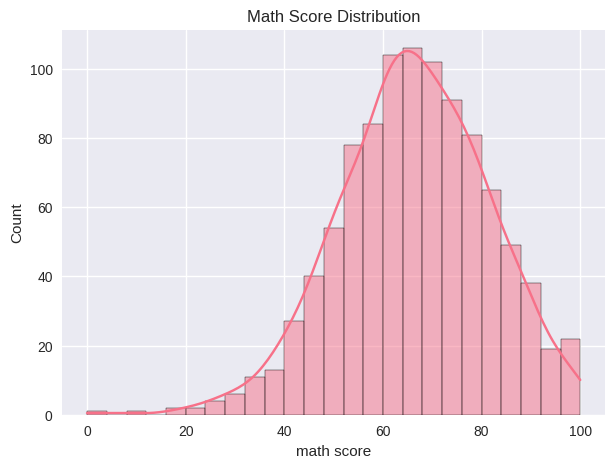

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(df["math score"],kde=True)

plt.title("Math Score Distribution")

plt.show()

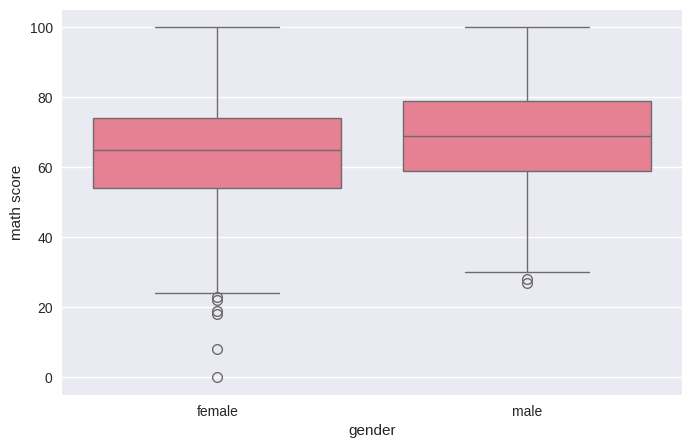

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="gender",y="math score",data=df)

plt.show()

In [ ]:
male=df[df["gender"]=="male"]["math score"]

female=df[df["gender"]=="female"]["math score"]

t,p=ttest_ind(male,female)

print("T Statistic :",t)

print("P Value :",p)

T Statistic : 5.383245869828983
P Value : 9.120185549328822e-08


In [ ]:
groups=[]

for name,data in df.groupby("parental level of education"):
    groups.append(data["math score"])

f,p=f_oneway(*groups)

print("F Statistic :",f)

print("P Value :",p)

F Statistic : 6.521582600453217
P Value : 5.592272384107223e-06


In [ ]:
table=pd.crosstab(
    df["gender"],
    df["test preparation course"]
)

chi,p,dof,expected=chi2_contingency(table)

print("Chi Square :",chi)

print("P Value :",p)

Chi Square : 0.015529201882465888
P Value : 0.9008273880804724


In [ ]:
le=LabelEncoder()

data=df.copy()

for col in data.select_dtypes(include="object"):
    data[col]=le.fit_transform(data[col])

In [ ]:
X=data.drop("math score",axis=1)

y=data["math score"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr=LinearRegression()

lr.fit(X_train,y_train)

pred=lr.predict(X_test)

print("R2 Score :",r2_score(y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

R2 Score : 0.8838026201112223
RMSE : 5.317450940660133


In [ ]:
rf=RandomForestRegressor()

rf.fit(X_train,y_train)

pred=rf.predict(X_test)

print("R2 Score :",r2_score(y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

R2 Score : 0.8461398720066977
RMSE : 6.118829738576273


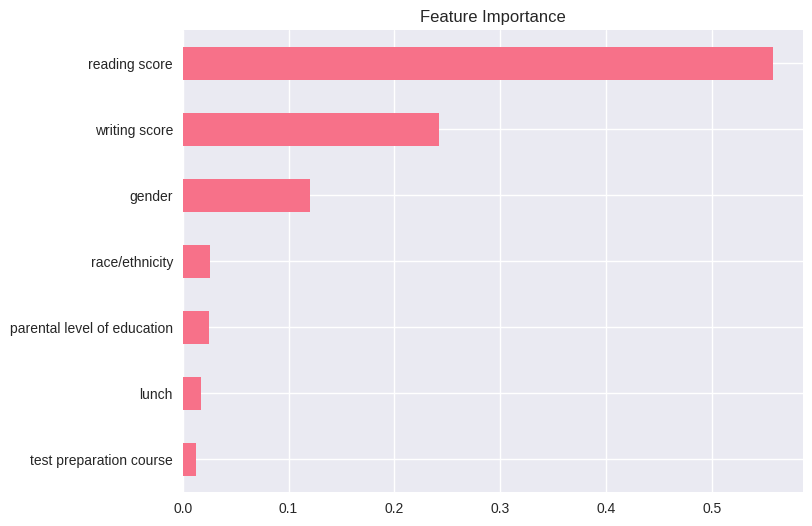

In [ ]:

importance=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()